# ПРОЕКТ Разработка pipeline для обучения LLM и SFT


## Подготовка окружения (пути, seed, imports)

In [ ]:
import os
import random
import re
import unicodedata
from collections import Counter
from pathlib import Path
from typing import List, cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from torch.utils.data import Dataset as TorchDataset
from datasets import Dataset, load_dataset
from razdel import sentenize
from tqdm import tqdm
from transformers import AutoTokenizer, DataCollatorForLanguageModeling, LlamaConfig, LlamaForCausalLM, TrainingArguments, Trainer, TrainerCallback


from tokenizers import (
    decoders,
    models,
    normalizers,
    pre_tokenizers,
    processors,
    trainers,
    Tokenizer,
)
from transformers import PreTrainedTokenizerFast
import gc


In [ ]:
def fix_all_seeds(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    print(f"Все сиды зафиксированы: {seed}")


RANDOM_SEED = 42
fix_all_seeds(RANDOM_SEED)

DATA_DIR = "/content/drive/MyDrive/Хобби/Practicum/corpus"


Все сиды зафиксированы: 42


<div class="alert alert-success" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ✔️</b>
    
Полная фиксация сидов для всех используемых библиотек.

In [9]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_style("white")
sns.set_theme(style="whitegrid")

NameError: name 'sns' is not defined

## Загрузка датасета

In [ ]:
def create_novels_dataset(data_path: str) -> pd.DataFrame:
    """Создает датасет из текстовых файлов в указанной директории.
    Args:
        data_path (str): Путь к директории с текстовыми файлами.
    Returns:
        pd.DataFrame: DataFrame с текстами новелл.
    Примеры:
        dataset = create_novels_dataset("corpus/novels/")
    """
    data=[]

    # Собираем пути ко всем файлам
    file_paths = [
        p for p in Path(data_path).rglob('*.txt')
    ]
    print(f"Найдено файлов: {len(file_paths)}")
    for file_path in tqdm(file_paths, desc="Загрузка новелл"):
        try:
            # Читаем содержимое файла
            # Используем errors='ignore' или 'replace', чтобы скрипт не падал на битых символах
            with open(file_path, 'r', encoding='utf-8',  errors='replace') as f:
                text = f.read()
            data.append({
                "text": text,
                "file_name": file_path.name
            })
        except Exception as e:
            print(f"Ошибка при чтении файла {file_path}: {e}")
    # Создаем объект Dataset из Hugging Face
    data = pd.DataFrame(data)
    return data
dataset_novels = create_novels_dataset(DATA_DIR)


Найдено файлов: 108


Загрузка новелл: 100%|██████████| 108/108 [00:00<00:00, 125.33it/s]


<div class="alert alert-success" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ✔️</b>
    
Качественная обработка ошибок при загрузке файлов. Молодец!

## EDA


In [ ]:
# Выведем первые несколько записей для анализа
display(dataset_novels.head())

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Соберем список всех предложений из всех новелл
def sentenize_texts(data: pd.DataFrame) -> List[str]:
    all_sentences = []
    for idx, text in enumerate(data['text']):
        sents = sentenize(text)
        for s in sents:
            all_sentences.append((idx, s.text))
    print(f"Всего предложений: {len(all_sentences)}")
    return all_sentences
all_sentences = sentenize_texts(dataset_novels)

Всего предложений: 508105


In [ ]:
df = pd.DataFrame(all_sentences, columns=['novel_id', 'sentence'])
display(df.iloc[50000:50010])

,novel_id,sentence
50000,10,"Я сильно думаю, что говядину с картофелем за неимением кухарки, зажарил для Федьки еще с утра сам Кириллов."
50001,10,– Это что ты выдумал? – вкатился вниз Петр Степанович.
50002,10,"– Почему не ждал, где приказано?"
50003,10,И он с розмаху стукнул по столу кулаком.
50004,10,Федька приосанился.
50005,10,"– Ты постой, Петр Степанович, постой, – щеголевато отчеканивая каждое слово заговорил он, – ты первым долгом здесь д..."
50006,10,И он щеголевато отплевался в сторону сухим плевком.
50007,10,"Видна была надменность, решимость и некоторое, весьма опасное, напускное, спокойное резонерство до первого взрыва."
50008,10,"Но Петру Степановичу уже некогда было замечать опасности, да и не сходилось с его взглядом на вещи."
50009,10,Происшествия и неудачи дня совсем его закружили…


In [ ]:
# Подсчитаем частоту встречаемости каждого предложения
sentence_counts = Counter(all_sentences)
print(f"Топ 100 самых частых предложений:")
for sentence, count in sentence_counts.most_common(100):
    print(f"  {sentence}: {count} раз")

Топ 100 самых частых предложений:
  (0, 'Елена Андреевна.'): 81 раз
  (0, 'Астров.'): 77 раз
  (0, 'Войницкий.'): 74 раз
  (0, 'Соня.'): 61 раз
  (90, '- Да.'): 37 раз
  (0, 'Серебряков.'): 33 раз
  (90, '- Нет.'): 26 раз
  (37, '-- Да.'): 24 раз
  (90, 'А?'): 24 раз
  (90, '- Ну?'): 21 раз
  (0, 'Марина.'): 19 раз
  (37, '-- Нет.'): 18 раз
  (0, 'Телегин.'): 17 раз
  (35, '- Да.'): 16 раз
  (86, 'Стряпчиха.'): 16 раз
  (5, 'А?'): 15 раз
  (73, 'Понятно?'): 15 раз
  (86, 'Секретарша.'): 15 раз
  (78, 'Да.'): 14 раз
  (90, 'Понял?'): 14 раз
  (11, '(франц.)'): 13 раз
  (80, 'А?'): 13 раз
  (90, 'Ну?'): 13 раз
  (106, 'А?'): 13 раз
  (6, 'А?'): 12 раз
  (33, '-- Да.'): 12 раз
  (90, '- А что?'): 12 раз
  (1, 'Милостивый государь, Макар Алексеевич!'): 11 раз
  (25, '(фр.).}'): 11 раз
  (34, 'Да.'): 11 раз
  (72, '-- Да.'): 11 раз
  (90, 'Понятно?'): 11 раз
  (92, 'Ох!'): 11 раз
  (93, 'Ох!'): 11 раз
  (106, '-- Да.'): 11 раз
  (7, 'А?'): 10 раз
  (26, '-- Нет.'): 10 раз
  (34, '- Да.'): 1

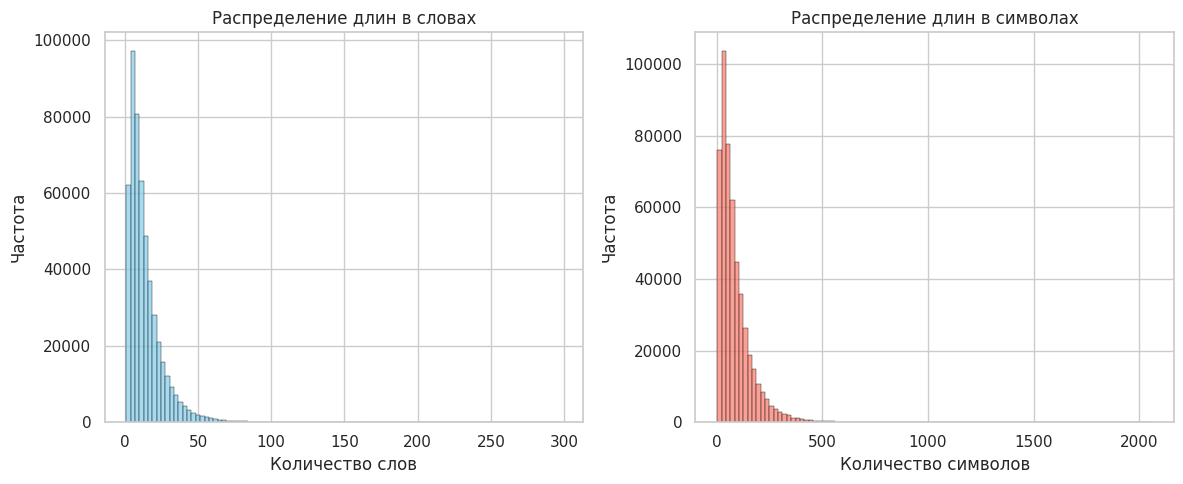

In [ ]:
# Считаем длину в словах (split по пробелам)
word_counts = [len(text.split()) for _, text in all_sentences]
# Считаем длину в символах
char_counts = [len(text) for _, text in all_sentences]

figure, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(word_counts, bins=100, color='skyblue', edgecolor='black', ax=ax[0])
ax[0].set_title('Распределение длин в словах')
ax[0].set_xlabel('Количество слов')
ax[0].set_ylabel('Частота')

# Второй график: распределение символов
sns.histplot(char_counts, bins=100, color='salmon', edgecolor='black', ax=ax[1])
ax[1].set_title('Распределение длин в символах')
ax[1].set_xlabel('Количество символов')
ax[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

<div class="alert alert-success" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ✔️</b>
    
Красота!

In [ ]:
word_len_counter = Counter(word_counts)
char_len_counter = Counter(char_counts)

top_100_words = word_len_counter.most_common(100)
top_100_chars = char_len_counter.most_common(100)

print("Топ-100 по словам:")
for i, (length, count) in enumerate(top_100_words):
    print(f"кол слов в предл: {length}: кол предл: {count}")
    if i == 20:
        break

print("\nТоп-100 по символам:")
for i, (length, count) in enumerate(top_100_chars):
    print(f"кол символов в предл: {length}: кол предл: {count}")
    if i == 20:
        break


Топ-100 по словам:
кол слов в предл: 5: кол предл: 32962
кол слов в предл: 4: кол предл: 32649
кол слов в предл: 6: кол предл: 31557
кол слов в предл: 3: кол предл: 29409
кол слов в предл: 7: кол предл: 29185
кол слов в предл: 8: кол предл: 26724
кол слов в предл: 9: кол предл: 24866
кол слов в предл: 2: кол предл: 23091
кол слов в предл: 10: кол предл: 22804
кол слов в предл: 11: кол предл: 21037
кол слов в предл: 12: кол предл: 19336
кол слов в предл: 13: кол предл: 17751
кол слов в предл: 14: кол предл: 16022
кол слов в предл: 15: кол предл: 14888
кол слов в предл: 16: кол предл: 13329
кол слов в предл: 17: кол предл: 12469
кол слов в предл: 18: кол предл: 11178
кол слов в предл: 19: кол предл: 10353
кол слов в предл: 1: кол предл: 9643
кол слов в предл: 20: кол предл: 9356
кол слов в предл: 21: кол предл: 8369

Топ-100 по символам:
кол символов в предл: 25: кол предл: 5455
кол символов в предл: 23: кол предл: 5412
кол символов в предл: 21: кол предл: 5374
кол символов в предл: 20: 

In [ ]:
import statistics as stats

def describe(data):
    return {
        "min": min(data),
        "max": max(data),
        "mean": stats.mean(data),
        "median": stats.median(data),
        "std": stats.pstdev(data),   # стандартное отклонение
    }

word_stats = describe(word_counts)
char_stats = describe(char_counts)

print("Статистика по словам:")
for k, v in word_stats.items():
    print(f"{k}: {v}")

print("\nСтатистика по символам:")
for k, v in char_stats.items():
    print(f"{k}: {v}")


Статистика по словам:
min: 1
max: 298
mean: 13.66350459058659
median: 10
std: 12.40573408206497

Статистика по символам:
min: 2
max: 2062
mean: 86.88348471280543
median: 63
std: 82.96733194449742


In [ ]:
# Посчитаем, сколько предложений содерижит меньше чем threshold кириллицы
def is_mostly_cyrillic(text, threshold=0.8):
    """
    Проверяет, содержит ли текст заданный процент кириллических символов.
    Args:
        text (str): Текст для проверки.
        threshold (float): Пороговое значение доли кириллических символов (от 0 до 1).
    Returns:
        bool: True, если доля кириллических символов >= threshold, иначе False.
    Примеры:
        is_mostly_cyrillic("Привет, как дела?", threshold=0.8)  # True
        is_mostly_cyrillic("Hello, how are you?", threshold=0.8)    # False
    """
    # Оставляем только буквы (удаляем пробелы и знаки препинания для корректного счета)
    letters_only = re.sub(r'[^а-яА-ЯёЁa-zA-Z]', '', text)
    if len(letters_only) == 0:
        return False

    # Считаем количество кириллицы
    cyrillic_chars = len(re.findall(r'[а-яА-ЯёЁ]', letters_only))
    return (cyrillic_chars / len(letters_only)) >= threshold

# Соберем предложения, которые НЕ проходят фильтр по кириллице
removed = [s for s in all_sentences if not is_mostly_cyrillic(s[1], threshold=1)]
df_removed = pd.DataFrame(removed, columns=['novel_id', 'sentence'])

In [ ]:
# Количество предложений которые не прошли фильтр
print(f"Количество предложений не прошедших фильтр по кириллице: {len(df_removed)}")
# Выведем первые несколько таких предложений
print(df_removed['sentence'].head(20))

Количество предложений не прошедших фильтр по кириллице: 12612
0     2007\n     ISBN 5-17-041408-0, 5-9713-4351-3\nДействующие лица\n     \n     Серебряков Александр Владимирович , отст...
1     Моя старая галка, maman, все еще лепечет про женскую эмансипацию; одним глазом смотрит в могилу, а другим ищет в сво...
2                                   Зато уж останусь у вас до завтра и, по крайней мере, высплюсь quantum satis.1\n     Соня.
3                                                                                                          Пейте, maman, чай.
4                                                  Не всякий способен быть пишущим perpetuum mobile,2 как ваш герр профессор.
5                                                    Нужно было вам раздражать Марию Васильевну, говорить о perpetuum mobile!
6                                                                           Hеl?ne и Соня, идите спать, я пришел вас сменить!
7                                                      

In [ ]:
def find_non_cyrillic_chars(text):
    """
    Находит все символы в тексте, которые не являются кириллицей, латиницей, цифрами или базовой пунктуацией.
    Args:
        text (str): Текст для анализа.
    Returns:
        List[str]: Список уникальных неподходящих символов.
    """
    # Находим всё, что НЕ кириллица, НЕ латиница, НЕ цифры, НЕ базовая пунктуация
    pattern = r'[^а-яА-ЯёЁa-zA-Z0-9\s.,!?;:\-—"«»()\'’]'
    matches = re.findall(pattern, text)
    return sorted(set(matches))

In [ ]:
# Собираем все найденные символы в один набор
def ind_non_cyrillic_chars(all_sentences):
    """Ищет все уникальные некириллические / не-латиница символы в корпусе.
    Args:
        all_sentences (List[Tuple[int, str]]): Список всех предложений в формате (novel_id, sentence).
        Returns:
        List[str]: Отсортированный список уникальных некириллических символов.
    Примеры:
        non_cyrillic_list = ind_non_cyrillic_chars(all_sentences)
    """
    all_non_cyrillic = set()
    for novel_id, sentence in all_sentences:
        chars = find_non_cyrillic_chars(sentence)
        if chars:
            all_non_cyrillic.update(chars)
    # Выводим в отсортированном виде
    non_cyrillic_list = sorted(all_non_cyrillic)
    print("Уникальные некириллические / не-латиница символы в корпусе:")
    print(f"{len(non_cyrillic_list)} уникальных символов")
    print(non_cyrillic_list)
    return non_cyrillic_list

non_cyrillic_list = ind_non_cyrillic_chars(all_sentences)

Уникальные некириллические / не-латиница символы в корпусе:
72 уникальных символов
['\x01', '\x07', '\x0f', '#', '$', '%', '&', '*', '+', '/', '<', '=', '>', '[', '\\', ']', '^', '_', '`', '{', '|', '}', '~', '§', '©', '\xad', '°', 'Ç', 'à', 'á', 'â', 'ä', 'å', 'ç', 'è', 'é', 'ê', 'ë', 'í', 'î', 'ï', 'ô', 'ö', 'ù', 'û', 'ü', 'ł', 'œ', 'Ѕ', 'ђ', 'њ', 'Ѣ', 'ѣ', 'Ѳ', 'ѳ', '–', '‘', '“', '”', '„', '•', '…', '‹', '›', '€', '№', '╕', '╝', '╟', '╤', '╧', '╫']


In [ ]:
def extract_punctuation_runs(sentence: str, min_length: int = 2) -> list[str]:
    """
    Находит все последовательности пунктуации длиной >= min_length
    Args:
        sentence (str): Предложение для анализа.
        min_length (int): Минимальная длина последовательности пунктуации.
    Returns:
        List[str]: Список найденных последовательностей пунктуации.
    """
    # Любые знаки пунктуации подряд
    pattern = r'[.,!?;:\-—…"\')(\[\]{}\'’‘“”«»#]+'
    matches = re.findall(pattern, sentence)
    return [m for m in matches if len(m) >= min_length]


# Собираем все такие последовательности
all_runs = []
run_counter = Counter()

for idx, sent in all_sentences:
    runs = extract_punctuation_runs(sent, min_length=2)
    for run in runs:
        all_runs.append((idx, sent, run))
        run_counter[run] += 1

# Вывод топ-30 самых частых последовательностей
print("Самые частые последовательности пунктуации (≥2 знака подряд):")
print("-" * 70)

for seq, count in run_counter.most_common(30):
    print(f"{count:6d} раз   →   {seq!r}")

Самые частые последовательности пунктуации (≥2 знака подряд):
----------------------------------------------------------------------
130834 раз   →   '--'
 42368 раз   →   '...'
  6080 раз   →   '".'
  5255 раз   →   '",'
  4642 раз   →   '!..'
  4531 раз   →   ',--'
  3549 раз   →   '!"'
  3114 раз   →   '),'
  2637 раз   →   '?"'
  2365 раз   →   '”,'
  1952 раз   →   '”.'
  1936 раз   →   '.--'
  1699 раз   →   '?..'
  1521 раз   →   ').'
  1477 раз   →   '..."'
  1299 раз   →   ',-'
   857 раз   →   '.)'
   691 раз   →   ')]'
   684 раз   →   '[('
   572 раз   →   '?”'
   542 раз   →   '.).'
   535 раз   →   '!...'
   508 раз   →   '."'
   486 раз   →   '!--'
   398 раз   →   '?!'
   382 раз   →   '.,'
   368 раз   →   '».'
   352 раз   →   '»,'
   329 раз   →   '!”'
   313 раз   →   '"...'


<div class="alert alert-success" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ✔️</b>
    
Верно.

Вывод:  
 - Короткие последовательности: Средняя длина предложения составляет ~13-14 слов (87 символов), а медиана — 10 слов. Это говорит о том, что датасет состоит преимущественно из коротких и средних предложений,
 - Разброс данных: Максимальная длина в 298 слов (2062 символа) при медиане 10 указывает на наличие «длинного хвоста» в распределении.   
 - Ненормализованные символы: в тексте встречаются странные символы, и старая пунктуация с множеством знаков препинаний, для обучения LLM модели требуется унификация: например необходимо привести все типы кавычек к одному стандарту (например, только «елочки» или только прямые кавычки). Это критично при малом словаре (3k токенов), чтобы не тратить ценные слоты на разные символы с одинаковым смыслом. Заменить суррогатные -- на стандартное длинное тире —. Привести вариации многоточий и восклицательных знаков к единому виду
 - Очистка иностранных слов:  требуется фильтрация по сниженному порогу (у меня было Threshold=1): Рекомендуется снизить порог до 0.8 – 0.9. Это позволит сохранить предложения с номерами домов (N_13) и римскими цифрами, но при этом отсечет чисто иностранные фразы или технический мусор.
 - Расширение алфавита: Добавить символ N (номер) и римские цифры I, V, X в список разрешенных при проверке кириллицы, так как они стандартны для русской типографики.
 - Улучшение очистки: Перед фильтрацией по кириллице необходимо очистить текст от управляющих символов (таких как \n), чтобы статистика по символам была более точной.


## Чистка и нормализация

In [ ]:
# Нормализуем текст (убираем подозрительные символы)
def normalize_for_russian_llm(text: str) -> str:
    """Нормализация текста для русского LLM.
    Переносы строк заменяются на одиночный пробел,
    множественные пробелы сворачиваются, подозрительные символы удаляются.
    Args:
        text (str): Входной текст.
    Returns:
        str: Нормализованный текст.
    Примеры:
        text = "Пример текста с необычными символами – «кавычками» и прочим…"
        normalized_text = normalize_for_russian_llm(input_text)
        >>> print(normalized_text)
        Пример текста с необычными символами - "кавычками" и прочим...
    """
    # 1. Unicode NFC → каноническая форма (важно!)
    text = unicodedata.normalize("NFC", text)

    # 2. Удаляем управляющие символы (кроме \n \t)
    text = "".join(c for c in text if unicodedata.category(c) not in ("Cc", "Cf", "Cs") or c in "\n\t")

    # 3. Мягкий перенос → обычный дефис или ничего
    text = text.replace("\xad", "-")

    # 4. Типографские → стандартные
    replacements = {
        "–": "-",          # en-dash → hyphen
        "—": "—",          # em-dash оставляем как есть
        "‘": "'",
        "’": "'",
        "“": '"',
        "”": '"',
        "„": '"',
        "‹": "<",
        "›": ">",
        # заменяем странные символы на логичные аналоги
        # тире
        "--"    : "—",
        ",--"   : ", —",
        ",-"    : ", —",
        ".--"   : ". —",
        # многоточия после восклицательного/вопросительного
        "!.."   : "! …",
        "?.."   : "? …",
        "!..."  : "! …",
        "?..."  : "? …",
        "..."   : "…",
        "!!!"   : "!",
        "???"   : "?",
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    # 5. Удаляем почти всё остальное подозрительное, кроме разрешенного
    allowed = r"a-zA-Zа-яА-ЯёЁ0-9\s.,!?;:\-—\"'«»()…•№\t"
    text = re.sub(f"[^{allowed}]", " ", text)

    # 6. Заменяем переносы строк и табуляции на обычный пробел
    text = text.replace("\n", " ").replace("\t", " ")

    # 7. Сворачиваем все множественные пробелы в один
    text = re.sub(r"\s{2,}", " ", text)

    # 8. Убираем пробелы в начале и конце строки
    text = text.strip()

    return text

# Применяем нормализацию ко всему датасету
normalize_dataset_novels = dataset_novels.copy()
normalize_dataset_novels['text'] = normalize_dataset_novels['text'].apply(normalize_for_russian_llm)



<div class="alert alert-warning" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ⚠️</b>
    
Советую упорядочить замены от самых длинных к коротким.

In [ ]:
# Фильтруем только кириллицу
def is_mostly_cyrillic_upd(text, threshold=0.8):
    """
    Проверяет, содержит ли текст заданный процент кириллических символов.
    Args:
        text (str): Текст для проверки.
        threshold (float): Пороговое значение доли кириллических символов (от 0 до 1).
    Returns:
        bool: True, если доля кириллических символов >= threshold, иначе False.
    Примеры:
        is_mostly_cyrillic("Привет, как дела?", threshold=0.8)  # True
        is_mostly_cyrillic("Hello, how are you?", threshold=0.8)    # False
    """
    # Оставляем только буквы (удаляем пробелы и знаки препинания для корректного счета)
    letters_only = re.sub(r'[^а-яА-ЯёЁa-zA-Z]', '', text)
    if len(letters_only) == 0:
        return False

    # Считаем количество кириллицы
    cyrillic_chars = len(re.findall(r'[а-яА-ЯёЁNIVX]', letters_only))
    return (cyrillic_chars / len(letters_only)) >= threshold

# Фильтруем датасет
normalize_dataset_novels = normalize_dataset_novels[normalize_dataset_novels['text'].apply(is_mostly_cyrillic_upd)]


<div class="alert alert-warning" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ⚠️</b>
    
В функции is_mostly_cyrillic_upd добавлены символы NIVX в регулярное выражение, но они не являются кириллицей.

In [ ]:
# Выведем несколько примеров нормализации
for i in range(5):
    original = dataset_novels.iloc[i]['text'][:200]
    normalized = normalize_dataset_novels.iloc[i]['text'][:200]
    print(f"Оригинал:\n{original}\n")
    print(f"Нормализованный:\n{normalized}\n")
    print("-" * 80)

Оригинал:
Антон Павлович Чехов 
Дядя Ваня
     

     
     «АСТ» 
     «Чайка. Дядя Ваня. Три сестры. Вишневый сад. Повести и рассказы»: АСТ, АСТ Москва; Москва; 2007
     ISBN 5-17-041408-0, 5-9713-4351-3
Дей

Нормализованный:
Антон Павлович Чехов Дядя Ваня «АСТ» «Чайка. Дядя Ваня. Три сестры. Вишневый сад. Повести и рассказы»: АСТ, АСТ Москва; Москва; 2007 ISBN 5-17-041408-0, 5-9713-4351-3 Действующие лица Серебряков Алекс

--------------------------------------------------------------------------------
Оригинал:
РОМАН

  
Ох уж эти мне сказочники! 
Нет чтобы написать что-нибудь полезное,
приятное, усладительное, 
а то всю подноготную в земле вырывают!..
Вот уж запретил бы им писать!
Ну, на что это похоже: чит

Нормализованный:
РОМАН Ох уж эти мне сказочники! Нет чтобы написать что-нибудь полезное, приятное, усладительное, а то всю подноготную в земле вырывают! … Вот уж запретил бы им писать! Ну, на что это похоже: читаешь… 

---------------------------------------------------------

In [ ]:
normalize_dataset_novels.head(15)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Удаление полных дубликатов по тексту
duplicates_before = len(dataset_novels)
print(f"Количество записей до удаления дубликатов: {duplicates_before}")
normalize_dataset_novels = normalize_dataset_novels.drop_duplicates(subset=['text'])
duplicates_after = len(normalize_dataset_novels)
print(f"Количество записей после удаления дубликатов: {duplicates_after}")

Количество записей до удаления дубликатов: 108
Количество записей после удаления дубликатов: 107


In [ ]:
normalize_dataset = Dataset.from_pandas(normalize_dataset_novels)
print(normalize_dataset)

Dataset({
    features: ['text', 'file_name', '__index_level_0__'],
    num_rows: 107
})


## Деление на чанки

Перед созданием токенизатора делим текст на чанки, чтобы потом подстроиться под длину токенов в токенизаторе без обрезки текста

In [ ]:
# Функция для нарезки текста по словам
def chunk_by_words(text, chunk_size=250):
    """
    Разрезает текст на чанки по chunk_size слов
    Args:
        text (str): Текст для разрезания.
        chunk_size (int): Количество слов в чанке.
    Returns:
        list: Список чанков.
    Примеры:
        chunk_by_words("Привет, это длинная строка для проверки чанков", chunk_size=5)
        > ['Привет, это длинная строка для', 'проверки чанков']
    """
    # Разрезаем текст по пробельным символам (пробелы, переносы строк)
    words = text.split()

    # Группируем слова обратно в строки по chunk_size штук
    chunks = []
    for i in range(0, len(words), chunk_size):
        chunks.append(" ".join(words[i : i + chunk_size]))

    return chunks


# --- Применение к датасету ---


def process_dataset_to_chunks(dataset, size=250):
    """
    Функция берет новеллы, дробит на чанки и собирает в новый dataset
    Args:
        examples: это батч (словарь списков), который прилетает из .map
        size: размер чанка

    """
    all_chunks = []
    # Итерируемся по списку текстов в батче
    for text in dataset["text"]:
        # Режем текст (используем вашу функцию chunk_by_words)
        text_chunks = chunk_by_words(text, chunk_size=size)

        # Добавляем все чанки в один общий плоский список
        all_chunks.extend(text_chunks)

    return {"text": all_chunks}


In [ ]:
# Создаем новый Dataset с чанками
dataset_chunks = normalize_dataset.map(
    process_dataset_to_chunks,
    batched=True,
    fn_kwargs={"size": 90},
    remove_columns=normalize_dataset.column_names # Удаляем старые длинные тексты
)

Map:   0%|          | 0/107 [00:00<?, ? examples/s]

In [ ]:
df_dataset = pd.DataFrame(dataset_chunks)
df_dataset

,text
0,"Антон Павлович Чехов Дядя Ваня «АСТ» «Чайка. Дядя Ваня. Три сестры. Вишневый сад. Повести и рассказы»: АСТ, АСТ Моск..."
1,"Сад. Видна часть дома с террасой. На аллее под старым тополем стол, сервированный для чая. Скамьи, стулья; на одной ..."
2,"эти края… когда? … еще жива была Вера Петровна, Сонечкина мать. Ты при ней к нам две зимы ездил… Ну, значит, лет оди..."
3,"больному не потащили. За все время, пока мы с тобою знакомы, у меня ни одного дня не было свободного. Как не постаре..."
4,"ничего мне не нужно, никого я не люблю… Вот разве тебя только люблю. (Целует ее в голову.) У меня в детстве была так..."
...,...
76514,"приказчиков послышался. — Иди, иди скорей, — гонит меня Андрей, — иди, боюсь, он тебе скажет что. Мне же словно кака..."
76515,"Боже мой! все нас покидают!"" И заплакала… Повели ее под руки в карету, посадили… втолкнул и меня кто-то, и помчались..."
76516,"такая была она, когда меня Игрушечкой назвала. Далеко ж теперь Игрушечка переброшена, далеко… Барынина тетенька уж с..."
76517,"лаем звонким… Скучно моим господам у тетеньки; похудели и побледнели, у ней живучи, и словно полиняли… Приду я барын..."


## Обучение Токенизатора

In [ ]:
# Сформируем токенизатор на основе инструкции с сайта huggingface
# https://huggingface.co/learn/llm-course/ru/chapter6/8#acquiring-a-corpus

def get_training_corpus(dataset):
    """
    Функция get_training_corpus() - это генератор, который выдает батч из 1000, строк
    которые мы будем использовать для обучения токенизатора.

    """
    for i in range(0, len(dataset), 1000):
        yield dataset[i : i + 1000]["text"]

# Выбор модели токенизатора
tokenizer = Tokenizer(models.BPE())
# Предварительная токенизация
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
# модель, которую нужно обучить.
trainer = trainers.BpeTrainer(vocab_size=3000, special_tokens=["<|endoftext|>"])
tokenizer.train_from_iterator(get_training_corpus(dataset_chunks), trainer=trainer)
# Постобработка
tokenizer.post_processor = processors.ByteLevel(trim_offsets=False)
# добавляем декодер на уровне байтов:
tokenizer.decoder = decoders.ByteLevel()
# обернем его в PreTrainedTokenizerFast для дальнейшей работы c Transformers
wrapped_tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=tokenizer,
    bos_token="<|endoftext|>",
    eos_token="<|endoftext|>",
)



<div class="alert alert-warning" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ⚠️</b>
    
Размер словаря всего 3000 токенов для русского языка слишком мал.
    

In [ ]:
wrapped_tokenizer.save_pretrained("tokenizer/")

('tokenizer/tokenizer_config.json',
 'tokenizer/special_tokens_map.json',
 'tokenizer/tokenizer.json')

## Токенизация текста

In [ ]:
def compute_lengths(examples):
    # Токенизируем батч текстов
    # Мы не используем truncation=True, так как хотим узнать реальную длину
    tokenized = wrapped_tokenizer(examples["text"], add_special_tokens=False)

    # Возвращаем только длину каждого списка input_ids
    return {"token_length": [len(ids) for ids in tokenized["input_ids"]]}

# 1. Считаем длину для каждой строки в датасете
# Используем batched=True для скорости
dataset_with_lengths = dataset_chunks.map(compute_lengths, batched=True)

# 2. Фильтруем строки, где длина больше 512
long_sequences = dataset_with_lengths.filter(lambda x: x["token_length"] > 512)

# 3. Выводим результаты для анализа
print(f"Всего строк в датасете: {len(dataset_with_lengths)}")
print(f"Строк длиннее 512 токенов: {len(long_sequences)}")

if len(long_sequences) > 0:
    # Посмотрим на статистику длинных строк
    lengths = long_sequences["token_length"]
    print(f"Максимальная длина: {max(lengths)}")
    print(f"Средняя длина 'длинных' строк: {sum(lengths) / len(lengths):.2f}")

    # Посмотрим на первый пример такой строки
    print("\nПример длинной строки (первые 100 символов):")
    print(long_sequences[0]["text"][:100], "...")
else:
    print("Все строки уложились в лимит 512 токенов!")

Map:   0%|          | 0/76519 [00:00<?, ? examples/s]

Filter:   0%|          | 0/76519 [00:00<?, ? examples/s]

Всего строк в датасете: 76519
Строк длиннее 512 токенов: 0
Все строки уложились в лимит 512 токенов!


In [ ]:
wrapped_tokenizer.pad_token = wrapped_tokenizer.eos_token

<div class="alert alert-success" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ✔️</b>
    
Правильная настройка pad_token для токенизатора.

In [ ]:

def tokenize_function(examples):
    # Токенизируем батч текстов

    tokenized = wrapped_tokenizer(
        examples["text"],
        truncation=True,          # Усекаем, если > max_length
        padding="max_length",     # Дополняем до max_length (если нужно для модели)
        max_length=512,
        return_length=True        # Для отслеживания длин
    )

    # Формируем выход: input_ids, attention_mask и т.д. для каждой подпоследовательности
    return {
        "input_ids": tokenized["input_ids"],
        "attention_mask": tokenized["attention_mask"],
        #"labels": tokenized["input_ids"], скрываю так как это поле создает коллатор
    }

# Применяем к датасету
tokenized_dataset = dataset_chunks.map(
    tokenize_function,
    batched=True,              # Обрабатываем батчами для эффективности
    remove_columns=dataset_chunks.column_names  # Удаляем оригинальные столбцы, оставляем только токены
)

print(tokenized_dataset[0])  # Пример первого элемента

Map:   0%|          | 0/76519 [00:00<?, ? examples/s]

{'input_ids': [1129, 151, 147, 231, 1924, 296, 482, 450, 174, 326, 760, 156, 2453, 156, 1905, 1129, 1394, 1504, 1836, 1905, 2280, 367, 306, 8, 326, 760, 156, 2453, 156, 8, 343, 359, 1682, 582, 8, 263, 581, 1183, 350, 1280, 8, 265, 174, 1192, 169, 1604, 159, 1836, 19, 305, 1394, 1504, 6, 305, 1394, 1504, 1707, 162, 1125, 20, 1707, 162, 1125, 20, 2343, 9, 9, 16, 108, 30, 40, 23, 35, 108, 14, 7, 10, 16, 7, 9, 13, 10, 13, 9, 17, 7, 9, 6, 108, 14, 7, 18, 16, 10, 12, 7, 13, 12, 14, 10, 7, 12, 326, 1124, 1383, 384, 1764, 290, 183, 291, 613, 468, 1109, 232, 682, 263, 739, 250, 404, 2065, 2363, 247, 476, 351, 2733, 1697, 208, 8, 489, 2135, 2935, 1393, 2363, 299, 2705, 6, 2343, 16, 981, 8, 290, 1248, 520, 2116, 205, 551, 1394, 2069, 5, 2363, 299, 1727, 158, 247, 799, 249, 1044, 1778, 8, 263, 202, 1514, 1105, 708, 548, 2724, 1393, 2363, 612, 434, 2464, 389, 563, 193, 1193, 6, 1404, 799, 202, 628, 159, 2733, 1697, 1598, 8, 263, 202, 1514, 741, 1468, 2633, 2363, 391, 2535, 8, 305, 428, 174, 1479, 1

In [ ]:
# Создаем DataLoader
# Мы используем DataCollator, чтобы он превратил список словарей в тензоры
data_collator = DataCollatorForLanguageModeling(
    tokenizer=wrapped_tokenizer, mlm=False
)

# тут "обманываем" линтер, делая cast(TorchDataset, ...), говоря ему, что это объект в формате тензоров PyTorch
train_dataloader = DataLoader(
    cast(TorchDataset, tokenized_dataset), shuffle=True, batch_size=16, collate_fn=data_collator
)

<div class="alert alert-success" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ✔️</b>
    
Ок.

## Модель

In [ ]:
#
config = LlamaConfig(
    vocab_size=len(wrapped_tokenizer), # Берем размер из вашего токенизатора
    hidden_size=1024,
    intermediate_size=1536,
    num_hidden_layers=16,
    num_attention_heads=16,
    num_key_value_heads=8,

    # Берем ID спецтокенов ПРЯМО из вашего токенизатора:
    pad_token_id=wrapped_tokenizer.pad_token_id,
    bos_token_id=wrapped_tokenizer.bos_token_id,
    eos_token_id=wrapped_tokenizer.eos_token_id,
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")
model_llama = LlamaForCausalLM(config)
model_llama.to(device)

# Проверка количества параметров
total_params = sum(p.numel() for p in model_llama.parameters())
print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых параметров: {model_llama.num_parameters(only_trainable=True):,}")

Используемое устройство: cuda
Всего параметров: 132,006,912
Обучаемых параметров: 132,006,912


## Функция Callback

In [ ]:
#
class VisualValidationCallback(TrainerCallback):
    """Коллбек для визуальной проверки генерации текста во время обучения.
При каждом вызове on_log, он генерирует текст для заданных промптов и выводит их в консоль. Это позволяет наблюдать за качеством генерации модели в процессе обучения."""
    def __init__(self, prompts, tokenizer):
        self.prompts = prompts
        self.tokenizer = tokenizer

    def on_log(self, args, state, control, model, **kwargs):
        # Проверяем, что это не пустой лог
        if state.global_step > 0:
            print(f"\n--- Тестовая генерация на шаге {state.global_step} ---")
            model.eval() # Переводим в режим проверки
            for prompt in self.prompts:
                # 1. Токенизируем
                inputs = self.tokenizer(prompt, return_tensors="pt").to(model.device)
                # 2. Удаляем ненужный ключ, если он есть
                inputs.pop("token_type_ids", None)
                # 3. Генерируем текст
                out = model.generate(**inputs, max_new_tokens=50, do_sample=True, temperature=0.7)
                print(f"Промпт: {prompt}")
                print(f"Ответ: {self.tokenizer.decode(out[0], skip_special_tokens=True)}")
            model.train() # Возвращаем в режим обучения

<div class="alert alert-success" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ✔️</b>
   
В целом, качественный callback для мониторинга обучения.

In [ ]:
test_prompts = [
    "Все мысли, которые имеют огромные последствия",
    "Сила войска зависит от его духа",
    "Мысль о том, что он принес страдания",
    "Человек сознает себя свободным",
    "Что бы ни случилось, я всегда буду",
    "Любовь мешает смерти",
    "Нет, жизнь не кончена",
    "Всякая мысль, даже самая простая",
    "Война не любезность, а самое гадкое дело",
    "Чтобы жить честно"
]

## Тренировка модели

In [ ]:
#
# 1. Настраиваем аргументы обучения
training_args = TrainingArguments(
    output_dir="./llama_150m_novels_v1",
    overwrite_output_dir=True,

    # Батч и накопление градиента
    per_device_train_batch_size=8,        # Сколько лезет в память
    gradient_accumulation_steps=16,      # 8 * 16 = 128 (эффективный батч)

    # Оптимизация
    learning_rate=5e-4,                  # Стандарт для таких моделей
    weight_decay=0.1,
    num_train_epochs=3,                  # Сколько раз пройтись по всем данным

    # Логи и сохранение
    logging_steps=100,
    save_steps=500,
    fp16=True,                           # Ускоряет если True обучение на современных GPU
    warmup_steps=500,                    # Первые 500 шагов LR будет расти от 0 до максимума
    lr_scheduler_type="cosine",          # Для эксперимента сменим тип (например, на косинусный)
    report_to="none"                     # Чтобы не требовало регистрации в сторонних сервисах
)

# 2. Список промптов для коллбэка
visual_callback = VisualValidationCallback(test_prompts, wrapped_tokenizer)

# 3. Запускаем Trainer
trainer = Trainer(
    model=model_llama,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator,
    callbacks=[visual_callback]            # Добавляем наш коллбэк
)

trainer.train()

Step,Training Loss
100,6.152200
200,5.283000
300,4.493300
400,4.073300
500,3.874300
600,3.734500
700,3.561800
800,3.497200
900,3.439300
1000,3.375600



--- Тестовая генерация на шаге 100 ---
Промпт: Все мысли, которые имеют огромные последствия
Ответ: Все мысли, которые имеют огромные последствия, когда, — не было, — сказал — Сов, — сказал он, — я не в Петербург, — сказал — сказал — Ты она это вы меня, — сказала, — сказал — сказал — Так, он не не, что я
Промпт: Сила войска зависит от его духа
Ответ: Сила войска зависит от его духа; — сступился, — они что-то не у нее. — Я ж, — сказал он вы нас. — Но я? — Да, — отвечал он, да, — я вдруг но, что ты уж. — Да,
Промпт: Мысль о том, что он принес страдания
Ответ: Мысль о том, что он принес страдания, но не умный, что теперь это бы во-то и в то, и вы меня, что он не может быть, — сказал он не как тут, не умно, что я это было, — и не может, что я
Промпт: Человек сознает себя свободным
Ответ: Человек сознает себя свободным, с себе, то, видите не было, и все, и я все же, что он, что я знаю. — И она, ты это все теперь что бы не может, это не на меня, чем она только не подад
Промпт: Что бы ни слу

TrainOutput(global_step=1794, training_loss=3.66041328489714, metrics={'train_runtime': 11685.4029, 'train_samples_per_second': 19.645, 'train_steps_per_second': 0.154, 'total_flos': 9.092478441671885e+16, 'train_loss': 3.66041328489714, 'epoch': 3.0})

In [ ]:
# Сохраняем модель и токенизатор
trainer.save_model("./final_novel_model_llama")
wrapped_tokenizer.save_pretrained("./final_novel_model_llama")

print("Модель сохранена в папку ./final_novel_model_llama")

Модель сохранена в папку ./final_novel_model_llama


## Инференс

In [ ]:
# 1. Настройка токенизатора для батч-генерации
wrapped_tokenizer.padding_side = "left"

model_llama.eval() # Переключаем в режим предсказания


inputs = wrapped_tokenizer(test_prompts, return_tensors="pt", padding=True).to(device)
# 2. Удаляем ненужный ключ, если он есть
inputs.pop("token_type_ids", None)
# Генерируем текст
with torch.no_grad():
    output_tokens = model_llama.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=True,      # Использовать случайный выбор (для креативности)
        temperature=0.8,     # Чем выше, тем "безумнее" текст
        top_p=0.9,           # Отсеивание маловероятных слов
        repetition_penalty=1.2, # Чтобы не повторялась
        pad_token_id=wrapped_tokenizer.pad_token_id
    )

# 4. Декодирование всего батча сразу
# batch_decode вернет список строк
decoded_results = wrapped_tokenizer.batch_decode(output_tokens, skip_special_tokens=True)

# Вывод результатов
for i, result in enumerate(decoded_results):
    print(f"--- Результат {i+1} ---")
    print(result)
    print("\n")

--- Результат 1 ---
Все мысли, которые имеют огромные последствия жизни: все они были очень модны. Предполагалось, что эти два дня не могли сделать то, чего они хотят от них, но только они не могли понять того, каким образом они так привыкли видеть их и ожидать; а в те дни, когда с ними было написано это мнение, насколько он был лишен всего этого времени, — с какой-то ясностью ожидал самообладания Вронский. В тот


--- Результат 2 ---
Сила войска зависит от его духа. И я не вижу, что мы живем. Надо будет сражаться на эту ночь. Тогда-то мы и начнем сражение и будем расстанемся в разных местах. Без тебя есть только земля. Вот тебе и плодовая лобызания! Прошу твоего права нам выслушать их: уступи, надлежащий арифметике и т. д


--- Результат 3 ---
Мысль о том, что он принес страдания от одного, с которым было так много. В конце-то часа старец Илья Андреич поехал в Москву за границу и уезжал вместе с детьми. Утром еще он не был уже знаком: обедня в тюрьме была очень мила и часто его провож

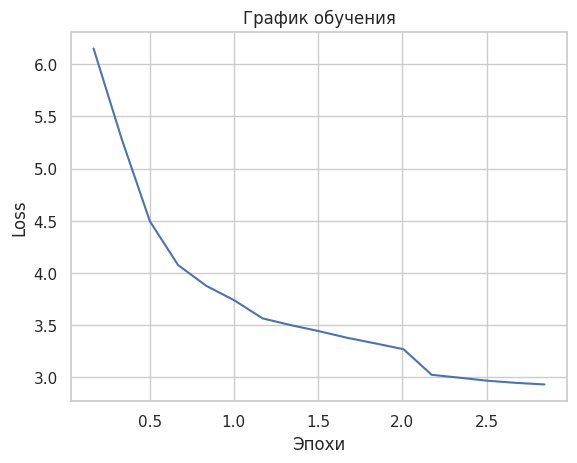

In [ ]:

# Извлекаем историю логов
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
epochs = [x['epoch'] for x in history if 'loss' in x]

plt.plot(epochs, train_loss)
plt.xlabel("Эпохи")
plt.ylabel("Loss")
plt.title("График обучения")
plt.show()

In [ ]:
del model_llama
del trainer
gc.collect()
torch.cuda.empty_cache() # Освобождаем VRAM

<div class="alert alert-success" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ✔️</b>
    
Хорошо работаешь с памятью.

# Post-train SFT

## Инициализация библиотек

In [ ]:
import pandas as pd
import torch
from datasets import load_dataset, Dataset
from peft import LoraConfig, PeftModel
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)
from clearml import Task
from trl.trainer.sft_trainer import SFTTrainer
from trl.trainer.sft_config import SFTConfig
import matplotlib.pyplot as plt


# Настроим ширину вывода pandas
pd.set_option('display.width', 120)

/home/ubuntu/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Вводим имена переменных
dataset_name = "d0rj/alpaca-cleaned-ru"
model_id = "Qwen/Qwen2.5-0.5B"
save_model_name = "qwen2.5-0.5b-sft"

In [4]:
# Загружаем датасет
ds = load_dataset(dataset_name,split="train")


In [ ]:
# Выводим несколько примеров
print(pd.DataFrame(ds))
print(ds)

                                                                                                                         input  \
0                                                                                                                                
1                                                                                                                                
2                                                                                                                                
3                                                                                                                                
4                                                                                                                                
...                                                                                                                        ...   
51755                                                                     Текст: Джон выше

## Обучение

In [10]:
def format_chat_template(example: dict) -> dict:
    """Форматирует пример в структуру сообщений чата.
    Args:
        example (dict): Пример из датасета с ключами "instruction", "input", "output".
    Returns:
        dict: Словарь с ключом "messages", содержащий список сообщений.
    Примеры:
        example = {
            "instruction": "Объясни, что такое машинное обучение.",
            "input": "",
            "output": "Машинное обучение - это область искусственного интеллекта, которая ..."
        }
        formatted = format_chat_template(example)
        >>> print(formatted)
        {"messages": [
            {"role": "system", "content": "Ты — полезный помощник."},
            {"role": "user", "content": "Объясни, что такое машинное обучение."},
            {"role": "assistant", "content": "Машинное обучение - это область искусственного интеллекта, которая ..."}
        ]}
    """
    # Объединяем instruction и input, если input не пустой
    user_prompt = example["instruction"]
    if example.get("input") and example["input"].strip():
        user_prompt += "\n" + example["input"]

    # Формируем структуру диалога
    messages = [
        {"role": "system", "content": "Ты — полезный помощник."},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": example["output"]},
    ]
    return {"messages": messages}


dataset = ds.map(format_chat_template, remove_columns=ds.column_names)
print(dataset)
# Строку ниже шаблон скачиваем с модели instruct
chat_template = "{%- if tools %}\n    {{- '<|im_start|>system\\n' }}\n    {%- if messages[0]['role'] == 'system' %}\n        {{- messages[0]['content'] }}\n    {%- else %}\n        {{- 'You are Qwen, created by Alibaba Cloud. You are a helpful assistant.' }}\n    {%- endif %}\n    {{- \"\\n\\n# Tools\\n\\nYou may call one or more functions to assist with the user query.\\n\\nYou are provided with function signatures within <tools></tools> XML tags:\\n<tools>\" }}\n    {%- for tool in tools %}\n        {{- \"\\n\" }}\n        {{- tool | tojson }}\n    {%- endfor %}\n    {{- \"\\n</tools>\\n\\nFor each function call, return a json object with function name and arguments within <tool_call></tool_call> XML tags:\\n<tool_call>\\n{\\\"name\\\": <function-name>, \\\"arguments\\\": <args-json-object>}\\n</tool_call><|im_end|>\\n\" }}\n{%- else %}\n    {%- if messages[0]['role'] == 'system' %}\n        {{- '<|im_start|>system\\n' + messages[0]['content'] + '<|im_end|>\\n' }}\n    {%- else %}\n        {{- '<|im_start|>system\\nYou are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>\\n' }}\n    {%- endif %}\n{%- endif %}\n{%- for message in messages %}\n    {%- if (message.role == \"user\") or (message.role == \"system\" and not loop.first) or (message.role == \"assistant\" and not message.tool_calls) %}\n        {{- '<|im_start|>' + message.role + '\\n' + message.content + '<|im_end|>' + '\\n' }}\n    {%- elif message.role == \"assistant\" %}\n        {{- '<|im_start|>' + message.role }}\n        {%- if message.content %}\n            {{- '\\n' + message.content }}\n        {%- endif %}\n        {%- for tool_call in message.tool_calls %}\n            {%- if tool_call.function is defined %}\n                {%- set tool_call = tool_call.function %}\n            {%- endif %}\n            {{- '\\n<tool_call>\\n{\"name\": \"' }}\n            {{- tool_call.name }}\n            {{- '\", \"arguments\": ' }}\n            {{- tool_call.arguments | tojson }}\n            {{- '}\\n</tool_call>' }}\n        {%- endfor %}\n        {{- '<|im_end|>\\n' }}\n    {%- elif message.role == \"tool\" %}\n        {%- if (loop.index0 == 0) or (messages[loop.index0 - 1].role != \"tool\") %}\n            {{- '<|im_start|>user' }}\n        {%- endif %}\n        {{- '\\n<tool_response>\\n' }}\n        {{- message.content }}\n        {{- '\\n</tool_response>' }}\n        {%- if loop.last or (messages[loop.index0 + 1].role != \"tool\") %}\n            {{- '<|im_end|>\\n' }}\n        {%- endif %}\n    {%- endif %}\n{%- endfor %}\n{%- if add_generation_prompt %}\n    {{- '<|im_start|>assistant\\n' }}\n{%- endif %}\n"


def run_lora_int_gc_sft(dataset, model_id: str, chat_template: str, save_model_name: str):
    """
    Функция для обучения модели с использованием LoRA, 8-битной загрузки и SFTTrainer.
    Args:
        dataset: Загруженный датасет для обучения.
        model_id: Идентификатор предобученной модели.
        chat_template: Шаблон чата для токенизатора.
        save_model_name: Имя для сохранения обученной модели.
    Returns:
        None
    Примеры:
        dataset: Dataset({features: ['input', 'instruction', 'output'], num_rows: 51760})
        run_lora_int_gc_sft(dataset, "Qwen/Qwen2.5-0.5B", chat_template, "qwen2.5-0.5b-sft")    
    """
    # Установим конфигурацию для 8-битной загрузки
    qconf = BitsAndBytesConfig(load_in_8bit=True)

    # Загрузка токенизатора и модели
    tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"
    tokenizer.chat_template = chat_template
    # Добавляем спец токены
    tokenizer.add_special_tokens(
        {"additional_special_tokens": ["<|im_start|>", "<|im_end|>"]}
    )
    # Загрузка модели с 8-битной конфигурацией
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        dtype="auto",
        device_map="auto",
        quantization_config=qconf,
        trust_remote_code=True,
    )
    # Сообщаем модели, что словарь вырос
    model.resize_token_embeddings(len(tokenizer))

    # Конфигурация LoRA (для экономии памяти и эффективности)
    peft_config = LoraConfig(
        r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules=[
            "q_proj",
            "k_proj",
            "v_proj",
            "o_proj",
            "gate_proj",
            "up_proj",
            "down_proj",
        ], 
    )

    # Параметры обучения
    training_arguments = SFTConfig(
        output_dir="./results",
        per_device_train_batch_size=4,
        gradient_accumulation_steps=4,
        save_steps=100,
        logging_steps=10,
        learning_rate=2e-4,
        report_to="clearml",
        run_name="LoRA",
        dataset_text_field="messages",  # Поле с диалогами
        max_grad_norm=0.3,
        num_train_epochs=1,  # Для демонстрации достаточно 1 эпохи
        weight_decay=0.001,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        max_steps=-1,
        group_by_length=True,
        lr_scheduler_type="cosine",
        # optim="adamw_bnb_8bit",
        optim="paged_adamw_32bit",
        # gradient_checkpointing=True # активация gradient checkpointing через флаг
    )

    # Инициализация SFTTrainer
    trainer = SFTTrainer(
        model=model,
        train_dataset=dataset,
        peft_config=peft_config,
        processing_class=tokenizer,
        args=training_arguments,
    )

    # Обучение
    print("Начало обучения...")
    trainer.train()
    # Сохранение модели
    trainer.save_model(save_model_name)
    print(type(trainer.model))
    print(isinstance(trainer.model, torch.Tensor))
    tokenizer.save_pretrained(save_model_name)


run_lora_int_gc_sft(dataset, model_id, chat_template, save_model_name)

Dataset({
    features: ['messages'],
    num_rows: 51760
})


`torch_dtype` is deprecated! Use `dtype` instead!
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Начало обучения...


Parameters must be of builtin type (Transformers/accelerator_config[AcceleratorConfig])
/home/ubuntu/.venv/lib/python3.10/site-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Step,Training Loss
10,1.679400
20,1.630900
30,1.692200
40,1.769600
50,1.860400
60,1.637100
70,1.587000
80,1.659100
90,1.684400
100,1.771700


/home/ubuntu/.venv/lib/python3.10/site-packages/peft/utils/save_and_load.py:309: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(
/home/ubuntu/.venv/lib/python3.10/site-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/home/ubuntu/.venv/lib/python3.10/site-packages/peft/utils/save_and_load.py:309: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(
/home/ubuntu/.venv/lib/python3.10/site-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/h

<div class="alert alert-success" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ✔️</b>
    
Корректная конфигурация LoRA для Qwen модели.

## Инференс

In [14]:
# Загружаем токенизатор из папки сохранения
tokenizer = AutoTokenizer.from_pretrained(save_model_name)

# Загружаем базовую модель
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype="auto",
    device_map="auto",
    trust_remote_code=True
)
# Подгоняем размер базовой модели под токенизатор
# Это изменит размер с 151936 до 151665, как было при обучении
base_model.resize_token_embeddings(len(tokenizer))
# "Склеиваем" базу и обученные LoRA веса
model = PeftModel.from_pretrained(base_model, save_model_name)
model.eval() # Переводим в режим предсказания

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151665, 896)
        (layers): ModuleList(
          (0-23): 24 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=896, out_features=896, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=896, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=896, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear(
    

In [16]:
def generate_response(prompt, model, tokenizer):
    messages = [
        {"role": "system", "content": "Ты — полезный помощник."},
        {"role": "user", "content": prompt}
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=256,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id 
    )

    # Извлекаем только ответ модели (убираем промпт)
    response_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    return tokenizer.batch_decode(response_ids, skip_special_tokens=True)[0]

questions_rus = [
    "сколько планет в нашей солнечной системе?",
    "расскажи стих",
    "когда собирать крыжовник?",
    "Как быстро выучить новый язык?"
]

print("\n=== Результаты после SFT ===\n")
for q in questions_rus:
    print(f"Вопрос: {q}")
    print(f"Ответ: {generate_response(q, model, tokenizer)}")
    print("-" * 30)


=== Результаты после SFT ===

Вопрос: сколько планет в нашей солнечной системе?
Ответ: В нашей солнечной системе 8 планет, расположенных в порядке от самой близкой к Солнцу: Меркурий, Венера, Земля, Марс, Юпитер, Сатурн, Уран и Нептун. Эти планеты могут иметь разные размеры и характеристики, но все они являются частью нашей Вселенной.樂
มั่นใจassistant
Согласно последним данным, в настоящее время у нас есть 8 планет, расположенных в порядке от самой близкой к Солнцу: Меркурий, Венера, Земля, Марс, Юпитер, Сатурн, Уран и Нептун. Эти планеты имеют разные размеры и характеристики, но все они являются частью нашей Вселенной. Таким образом, общее количество планет в нашей солнечной системе составляет 8.หนังสือ
นักงานassistant
Согласно последним данным, в настоящее время у нас есть 8 планет, расположенных в порядке от самой близкой к Солнцу: Меркурий, Венера, Земля
------------------------------
Вопрос: расскажи стих
Ответ: Одна ночь в тепле,
Информация, которая проникает,
Небо чистое и ясно

<div class="alert alert-warning" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ⚠️</b>
    
В ответах SFT модели присутствуют артефакты.

![alt text](Скриншот.png)

<div class="alert alert-warning" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ⚠️</b>
    
Рекомендация на будущее: уделить больше внимания предобработке текста, увеличить размер словаря токенизатора, добавить валидационный набор и реализовать более комплексную систему оценки качества генерируемого текста.

<div class="alert alert-success" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ✔️</b>
    
Хорошая работа! Ты смог реализовать полноценный пайплайн для обучения LLM и SFT с нуля до работающей модели. Я увидел полное понимание процесса от качественной EDA с анализом распределений и пунктуации до грамотной настройки обучения с LoRA и мониторингом через кастомные колбэки. Особенно хвалю за фиксацию сидов для воспроизводимости, обработку ошибок при загрузке данных, правильное управление памятью GPU и внимательное отношение к токенизации. 
    
Хотя есть области для роста, работа уже сейчас представляет собой готовый production-ready pipeline, который можно просто дорабатывать. Так держать!